In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from datetime import datetime, timedelta
import dukascopy_python
from dukascopy_python.instruments import INSTRUMENT_FX_MAJORS_EUR_USD

In [ ]:
from pathlib import Path

NOTEBOOK_DIR = Path("/Users/catoccino/Desktop/FX INT SYSTEM/FX-INTELLIGENCE-SYSTEM/lit_rew_&_stylised_facts")

start = datetime(2025, 1, 1)
end = datetime(2025, 12, 31)

parquet_path = NOTEBOOK_DIR / "raw_ticks_cache.parquet"

In [4]:
raw_ticks = pd.read_parquet(parquet_path)
raw_ticks['mid'] = (raw_ticks['bidPrice']+ raw_ticks['askPrice'])/2
raw_ticks['mid'].head()
d = raw_ticks['mid'].resample('1s').last().ffill()


In [5]:
d = pd.DataFrame(d)
d['log_return'] = np.log(d['mid']/d['mid'].shift(1))

In [6]:
window = "1h"
sq_returns = d['log_return']**2
rv_window = sq_returns.rolling(window).sum()


In [7]:
baseline_adaptive = rv_window.rolling("30D").mean()

In [8]:
variance_ratio_adaptive = rv_window / baseline_adaptive
 
print("Variance ratio (adaptive baseline) stats:")
print(variance_ratio_adaptive.describe(), "\n")

def classify(ratio):
    if pd.isna(ratio):
        return np.nan
    if ratio < 0.5:
        return "calm"
    elif ratio < 1.5:
        return "normal"
    elif ratio < 3.0:
        return "elevated"
    else:
        return "heated"
 
regime = variance_ratio_adaptive.apply(classify)
print("Time spent in each regime (adaptive baseline):")
print(regime.value_counts(normalize=True), "\n")

Variance ratio (adaptive baseline) stats:


count    3.136677e+07
mean     9.788164e-01
std      2.601061e+00
min      0.000000e+00
25%      0.000000e+00
50%      5.037310e-01
75%      1.137813e+00
max      1.665810e+02
Name: log_return, dtype: float64 



Time spent in each regime (adaptive baseline):
log_return
calm        0.497902
normal      0.329793
elevated    0.120395
heated      0.051911
Name: proportion, dtype: float64 



/var/folders/6n/0n62hfmn0wb7slbnjxdhg79c0000gn/T/ipykernel_61525/2219543077.py:9: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


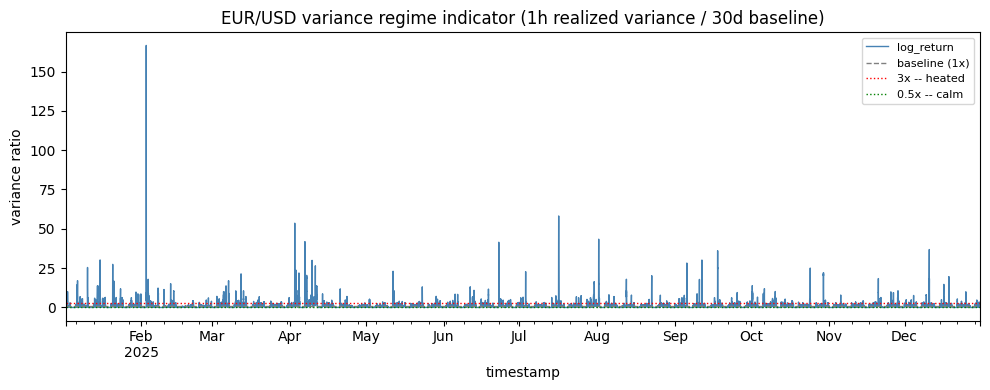

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
variance_ratio_adaptive.plot(ax=ax, lw=1, color="steelblue")
ax.axhline(1.0, color="gray", ls="--", lw=1, label="baseline (1x)")
ax.axhline(3.0, color="red", ls=":", lw=1, label="3x -- heated")
ax.axhline(0.5, color="green", ls=":", lw=1, label="0.5x -- calm")
ax.set_title("EUR/USD variance regime indicator (1h realized variance / 30d baseline)")
ax.set_ylabel("variance ratio")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [10]:
print("Read the ratio directly: 'It is as if information is flowing")
print(f"{variance_ratio_adaptive.iloc[-1]:.1f}x as quickly as normal right now'")
print("(using the most recent value in the series).")

Read the ratio directly: 'It is as if information is flowing
0.4x as quickly as normal right now'
(using the most recent value in the series).


In [ ]:
start = datetime(2026, 1, 1)
end = datetime(2026, 3, 31)

parquet_path = NOTEBOOK_DIR / "raw_ticks_2026.parquet"

if parquet_path.exists():
    raw_ticks_2026 = pd.read_parquet(parquet_path)
    print(f"Loaded {len(raw_ticks_2026):,} ticks from {parquet_path}")
else:
    raw_ticks_2026 = dukascopy_python.fetch(
        instrument=INSTRUMENT_FX_MAJORS_EUR_USD,
        interval=dukascopy_python.INTERVAL_TICK,
        offer_side=dukascopy_python.OFFER_SIDE_BID,
        start=start,
        end=end,
    )
    parquet_path.parent.mkdir(parents=True, exist_ok=True)
    raw_ticks_2026.to_parquet(parquet_path, index=True, compression="snappy")
    print(f"Fetched {len(raw_ticks_2026):,} ticks")
    print(f"Saved parquet: {parquet_path}")

print(f"Columns: {list(raw_ticks_2026.columns)}")
print(f"Range: {raw_ticks_2026.index.min()} -> {raw_ticks_2026.index.max()}")
raw_ticks_2026.head()

In [12]:
raw_ticks = pd.read_parquet(parquet_path)
raw_ticks['mid'] = (raw_ticks['bidPrice']+ raw_ticks['askPrice'])/2
raw_ticks['mid'].head()
d = raw_ticks['mid'].resample('1s').last().ffill()
d = d[d.index.dayofweek < 5]  # drop Sat/Sun (flat-filled, not real trading)

In [13]:
d = pd.DataFrame(d)
d['log_return'] = np.log(d['mid']/d['mid'].shift(1))

In [14]:
window = "1h"
sq_returns = d['log_return']**2
rv_window = sq_returns.rolling(window).sum()
baseline_adaptive = rv_window.rolling("30D").mean()

In [15]:
variance_ratio_adaptive = rv_window / baseline_adaptive
 
print("Variance ratio (adaptive baseline) stats:")
print(variance_ratio_adaptive.describe(), "\n")

def classify(ratio):
    if pd.isna(ratio):
        return np.nan
    if ratio < 0.5:
        return "calm"
    elif ratio < 1.5:
        return "normal"
    elif ratio < 3.0:
        return "elevated"
    else:
        return "heated"
 
regime = variance_ratio_adaptive.apply(classify)
print("Time spent in each regime (adaptive baseline):")
print(regime.value_counts(normalize=True), "\n")

Variance ratio (adaptive baseline) stats:
count    5.356518e+06
mean     1.245198e+00
std      2.842834e+00
min      0.000000e+00
25%      3.644438e-01
50%      6.872497e-01
75%      1.363536e+00
max      8.276552e+01
Name: log_return, dtype: float64 



Time spent in each regime (adaptive baseline):
log_return
normal      0.406441
calm        0.371108
elevated    0.159324
heated      0.063127
Name: proportion, dtype: float64 



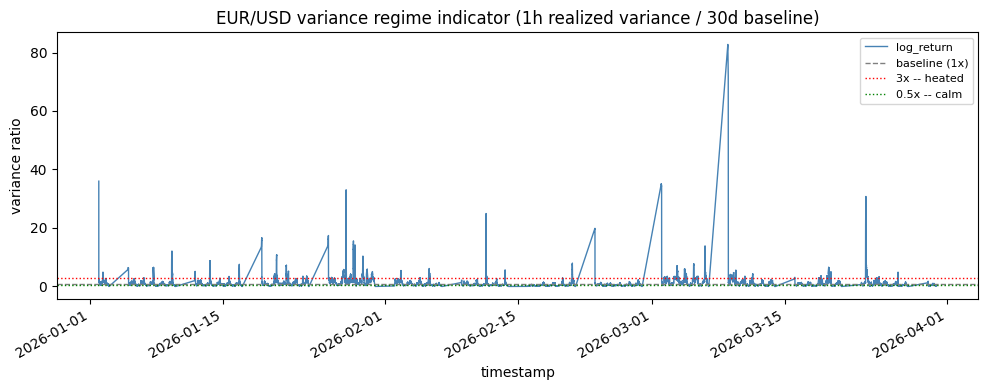

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
variance_ratio_adaptive.plot(ax=ax, lw=1, color="steelblue")
ax.axhline(1.0, color="gray", ls="--", lw=1, label="baseline (1x)")
ax.axhline(3.0, color="red", ls=":", lw=1, label="3x -- heated")
ax.axhline(0.5, color="green", ls=":", lw=1, label="0.5x -- calm")
ax.set_title("EUR/USD variance regime indicator (1h realized variance / 30d baseline)")
ax.set_ylabel("variance ratio")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:          log_rv_target   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.858
Method:                 Least Squares   F-statistic:                     3140.
Date:                Mon, 31 Aug 2026   Prob (F-statistic):               0.00
Time:                        20:07:56   Log-Likelihood:                -3062.6
No. Observations:                1554   AIC:                             6133.
Df Residuals:                    1550   BIC:                             6155.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.8983      1.277     -0.704

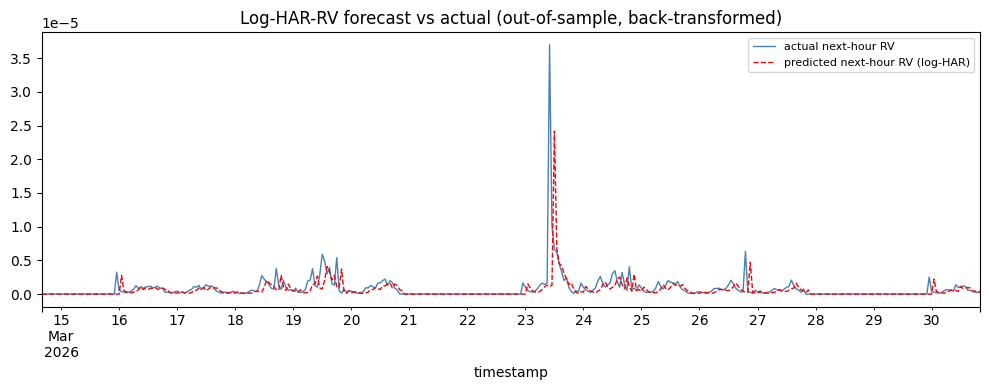

Compare model.params here vs. the raw-level run: coefficients are
now on log-RV, so read them as 'a 1% rise in this lag's variance
is associated with a beta% rise in next-hour variance' -- an
elasticity, not a direct level effect.


In [17]:
"""
Log-HAR-RV: same idea as har_rv_forecast.py, but fit in log-variance space
instead of raw levels. Realized variance is heavy-tailed / roughly
log-normal, so a handful of huge spikes dominate a raw-level OLS fit
(hence the near-flat predictions and low R^2 you got). Logging compresses
the spikes and is the standard fix used in the HAR-RV literature.
"""

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
sq_returns = d['log_return']**2
rv_hourly = sq_returns.resample("1h").sum().dropna()

df = pd.DataFrame({"rv": rv_hourly})
df["rv_lag1"] = df["rv"].shift(1)
df["rv_daily"] = df["rv"].shift(1).rolling(24).mean()
df["rv_weekly"] = df["rv"].shift(1).rolling(24 * 7).mean()
df["rv_target"] = df["rv"].shift(-1)
df = df.dropna()

# ---- log-transform everything (small epsilon guards against log(0)) ------
eps = df["rv"][df["rv"] > 0].min() * 1e-3
for col in ["rv", "rv_lag1", "rv_daily", "rv_weekly", "rv_target"]:
    df[f"log_{col}"] = np.log(df[col] + eps)

split = int(len(df) * 0.8)
train, test = df.iloc[:split], df.iloc[split:]

feature_cols = ["log_rv_lag1", "log_rv_daily", "log_rv_weekly"]
X_train = sm.add_constant(train[feature_cols])
y_train = train["log_rv_target"]
X_test = sm.add_constant(test[feature_cols], has_constant="add")
y_test = test["log_rv_target"]

model = sm.OLS(y_train, X_train).fit()
print(model.summary())
print("\nFitted kernel weights (K), log space:")
print(model.params, "\n")

# ---- out-of-sample R^2, both in log space and back-transformed levels ----
test_pred_log = model.predict(X_test)
ss_res = ((y_test - test_pred_log) ** 2).sum()
ss_tot = ((y_test - y_test.mean()) ** 2).sum()
oos_r2_log = 1 - ss_res / ss_tot

# back-transform to compare against the original raw-level plot
test_pred_level = np.exp(test_pred_log) - eps
y_test_level = np.exp(y_test) - eps
ss_res_lvl = ((y_test_level - test_pred_level) ** 2).sum()
ss_tot_lvl = ((y_test_level - y_test_level.mean()) ** 2).sum()
oos_r2_level = 1 - ss_res_lvl / ss_tot_lvl

print(f"In-sample R^2 (log space):      {model.rsquared:.4f}")
print(f"Out-of-sample R^2 (log space):  {oos_r2_log:.4f}")
print(f"Out-of-sample R^2 (raw levels): {oos_r2_level:.4f}")
print("(compare the raw-levels number directly against your previous run)\n")

# ---- plot: back-transformed predictions vs actual, same scale as before --
fig, ax = plt.subplots(figsize=(10, 4))
y_test_level.plot(ax=ax, label="actual next-hour RV", color="steelblue", lw=1)
test_pred_level.plot(ax=ax, label="predicted next-hour RV (log-HAR)", color="red", lw=1, ls="--")
ax.set_title("Log-HAR-RV forecast vs actual (out-of-sample, back-transformed)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Compare model.params here vs. the raw-level run: coefficients are")
print("now on log-RV, so read them as 'a 1% rise in this lag's variance")
print("is associated with a beta% rise in next-hour variance' -- an")
print("elasticity, not a direct level effect.")

                            OLS Regression Results                            
Dep. Variable:             ret_target   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                   0.06334
Date:                Mon, 31 Aug 2026   Prob (F-statistic):              0.979
Time:                        20:07:56   Log-Likelihood:                 9012.2
No. Observations:                1554   AIC:                        -1.802e+04
Df Residuals:                    1550   BIC:                        -1.799e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.265e-05   1.88e-05     -0.673      0.5

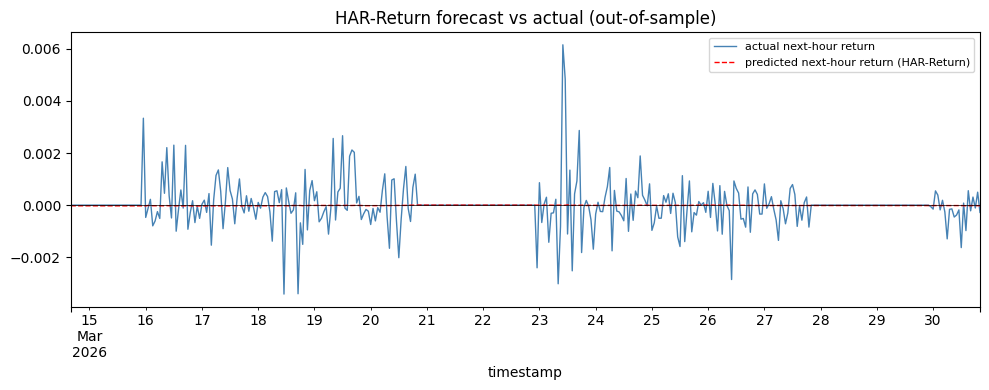

Compare model_r.params here vs. the RV cell: coefficients are on
raw signed returns, so a positive ret_lag1 coefficient means
momentum (last hour's direction tends to continue) and a negative
one means mean-reversion.


In [18]:
"""
HAR-Return: same HAR kernel structure as the log-HAR-RV cell above (lag1 +
rolling-24h "daily" + rolling-168h "weekly" features, OLS, 80/20 split),
but fit on signed hourly log-returns instead of squared returns. RV only
ever tells you the expected *size* of the next move; regressing on the
raw (signed) return lets the same lag/daily/weekly kernel also pick up
directional persistence (momentum) or mean-reversion, so the forecast
carries both magnitude and sign.

No log-transform here: unlike RV, returns are signed, so log(ret) isn't
defined. Returns are already far less heavy-tailed than squared returns,
so raw-level OLS is the natural fit (this is also why the RV cell had to
log-transform and this one doesn't).
"""

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

ret_hourly = d['log_return'].resample("1h").sum().dropna()

df_r = pd.DataFrame({"ret": ret_hourly})
df_r["ret_lag1"] = df_r["ret"].shift(1)
df_r["ret_daily"] = df_r["ret"].shift(1).rolling(24).mean()
df_r["ret_weekly"] = df_r["ret"].shift(1).rolling(24 * 7).mean()
df_r["ret_target"] = df_r["ret"].shift(-1)
df_r = df_r.dropna()

split_r = int(len(df_r) * 0.8)
train_r, test_r = df_r.iloc[:split_r], df_r.iloc[split_r:]

feature_cols_r = ["ret_lag1", "ret_daily", "ret_weekly"]
X_train_r = sm.add_constant(train_r[feature_cols_r])
y_train_r = train_r["ret_target"]
X_test_r = sm.add_constant(test_r[feature_cols_r], has_constant="add")
y_test_r = test_r["ret_target"]

model_r = sm.OLS(y_train_r, X_train_r).fit()
print(model_r.summary())
print("\nFitted kernel weights (K), return space:")
print(model_r.params, "\n")

# ---- out-of-sample R^2 -----------------------------------------------
test_pred_r = model_r.predict(X_test_r)
ss_res_r = ((y_test_r - test_pred_r) ** 2).sum()
ss_tot_r = ((y_test_r - y_test_r.mean()) ** 2).sum()
oos_r2_r = 1 - ss_res_r / ss_tot_r

print(f"In-sample R^2:      {model_r.rsquared:.4f}")
print(f"Out-of-sample R^2:  {oos_r2_r:.4f}\n")

# ---- directional accuracy: the thing RV could never give you ---------
# hit rate = how often sign(predicted next-hour return) matches
# sign(actual next-hour return). 0.5 is coin-flip; compare against the
# naive "predict same sign as last hour" baseline too.
pred_sign = np.sign(test_pred_r)
actual_sign = np.sign(y_test_r)
nonzero = actual_sign != 0
hit_rate = (pred_sign[nonzero] == actual_sign[nonzero]).mean()

naive_sign = np.sign(test_r["ret_lag1"])
naive_hit_rate = (naive_sign[nonzero] == actual_sign[nonzero]).mean()

print(f"Directional hit rate (HAR-Return):      {hit_rate:.4f}")
print(f"Directional hit rate (naive, sign(lag1)): {naive_hit_rate:.4f}")
print("(both vs. 0.5 coin-flip baseline)\n")

# ---- plot: predicted vs actual next-hour return, out-of-sample -------
fig, ax = plt.subplots(figsize=(10, 4))
y_test_r.plot(ax=ax, label="actual next-hour return", color="steelblue", lw=1)
test_pred_r.plot(ax=ax, label="predicted next-hour return (HAR-Return)", color="red", lw=1, ls="--")
ax.axhline(0, color="black", lw=0.5)
ax.set_title("HAR-Return forecast vs actual (out-of-sample)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("har_ret_forecast.png", dpi=150)
plt.show()

print("Compare model_r.params here vs. the RV cell: coefficients are on")
print("raw signed returns, so a positive ret_lag1 coefficient means")
print("momentum (last hour's direction tends to continue) and a negative")
print("one means mean-reversion.")
